# GAI Pipeline Baseline — Top 3 Regression Models

This notebook reproduces the paper's GAI pipeline **without PyCaret**, using the top 3
regression models from `compare_models.tsv` (CatBoost, Gradient Boosting, Random Forest).

We intentionally report **two baseline views**:
1. **Paper-comparable view**: behavior close to the original published workflow, for comparability.
2. **Strict generalization view**: leakage-safe nested CV, for realistic out-of-sample performance.

**Pipeline** (strict view runs entirely inside each CV fold):
1. Train age-regression on healthy training-fold samples
2. Predict gut age for held-out fold samples
3. Compute raw GAI and apply age-bin correction from training-fold stats
4. Classify healthy/non-healthy via logistic regression on corrected GAI
5. Optimize probability threshold for balanced accuracy

We run this for AGP and GGMP, with and without the 40-45 age-band fix (4 variants × 3 models = 12 rows).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
import time

pd.set_option("display.precision", 4)
SEED = 123  # matches pycaret session_id in gai_cal.py

## 1. Data loading

Load both datasets' processed meta + OTU files.

In [6]:
def load_dataset(name):
    """Load meta and OTU for a dataset, align indices, return (meta, otu)."""
    base = f"data/processed/{name}"
    meta = pd.read_csv(f"{base}/meta.tsv", sep="\t", index_col="id")
    otu = pd.read_csv(f"{base}/otu.tsv", sep="\t", index_col="id")
    common = meta.index.intersection(otu.index)
    meta, otu = meta.loc[common], otu.loc[common]
    return meta, otu

datasets = {}
for ds_name in ["AGP", "GGMP"]:
    meta, otu = load_dataset(ds_name)
    y = (meta["health"] == "n").astype(int).values
    print(f"{ds_name}: {len(meta)} samples | Healthy: {(y==0).sum()} | Non-healthy: {(y==1).sum()} | OTUs: {otu.shape[1]}")
    datasets[ds_name] = {"meta": meta, "otu": otu, "y": y}

AGP: 5965 samples | Healthy: 1852 | Non-healthy: 4113 | OTUs: 1329
GGMP: 6242 samples | Healthy: 1178 | Non-healthy: 5064 | OTUs: 1240


## 2. Age-bin adjustment values

The paper corrects raw GAI by subtracting the mean raw GAI of healthy individuals in each age bin.
The original code has a **bug**: it skips the 40-45 age bracket. We test both variants.

In [7]:
AGE_BINS_BUGGY = [
    (18, 20), (20, 25), (25, 30), (30, 35), (35, 40),
    # (40, 45) missing — the original bug
    (45, 50), (50, 55), (55, 60), (60, 65),
    (65, 70), (70, 75), (75, 100),
]

AGE_BINS_FIXED = [
    (18, 20), (20, 25), (25, 30), (30, 35), (35, 40),
    (40, 45),  # fix
    (45, 50), (50, 55), (55, 60), (60, 65),
    (65, 70), (70, 75), (75, 100),
]

## 3. GAI pipeline (nested CV)

The entire pipeline runs inside each CV fold: regression training, GAI computation, bias correction, and classification all use only training-fold data, with evaluation on the held-out test fold. This avoids the in-sample overfitting where regression models memorize healthy ages.

In [8]:
def compute_adjust_values(ages, raw_gai, health, age_bins):
    """Compute per-bin mean raw GAI for healthy individuals."""
    adjust = {}
    for lo, hi in age_bins:
        mask = (health == "y") & (ages >= lo) & (ages < hi)
        if mask.sum() > 0:
            adjust[(lo, hi)] = raw_gai[mask].mean()
        else:
            adjust[(lo, hi)] = np.nan
    return adjust


def assign_adjust_value(ages, adjust_dict):
    """Map each sample to its age-bin adjustment value."""
    result = np.full(len(ages), np.nan)
    for (lo, hi), val in adjust_dict.items():
        mask = (ages >= lo) & (ages < hi)
        result[mask] = val
    return result


def run_gai_pipeline(meta, otu, make_reg_fn, age_bins, seed=SEED):
    """Full GAI pipeline with proper nested 5-fold CV.
    
    Inside each fold:
      1. Train age-regression on healthy samples from the TRAINING fold only
      2. Predict gut age for TEST fold samples
      3. Compute raw GAI and bias-correct using TRAINING fold healthy stats
      4. Classify via logistic regression (also train on train fold GAI)
    
    This avoids in-sample overfitting in the regression step.
    Also optimizes the probability threshold for balanced accuracy.
    """
    t0 = time.perf_counter()
    
    ages = meta["age"].values.astype(float)
    health = meta["health"].values
    y = (health == "n").astype(int)
    X_otu = otu.values
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_ba, fold_auc = [], []
    oof_probs = np.full(len(y), np.nan)
    oof_gai = np.full(len(y), np.nan)
    n_dropped_total = 0
    
    for tri, tei in cv.split(X_otu, y):
        # Train/test split
        health_tr = health[tri]
        ages_tr, ages_te = ages[tri], ages[tei]
        X_tr, X_te = X_otu[tri], X_otu[tei]
        y_tr, y_te = y[tri], y[tei]
        
        # 1. Train regression on TRAINING fold healthy only
        healthy_tr = health_tr == "y"
        reg = make_reg_fn()
        reg.fit(X_tr[healthy_tr], ages_tr[healthy_tr])
        
        # 2. Predict gut age for TRAIN (for adjustment calc) and TEST
        pred_age_tr = reg.predict(X_tr)
        pred_age_te = reg.predict(X_te)
        
        # 3. Raw GAI
        raw_gai_tr = pred_age_tr - ages_tr
        raw_gai_te = pred_age_te - ages_te
        
        # 4. Bias correction: compute from TRAINING healthy only
        adj_dict = compute_adjust_values(ages_tr, raw_gai_tr, health_tr, age_bins)
        adj_tr = assign_adjust_value(ages_tr, adj_dict)
        adj_te = assign_adjust_value(ages_te, adj_dict)
        
        corrected_tr = raw_gai_tr - adj_tr
        corrected_te = raw_gai_te - adj_te
        
        # Drop NaN (from missing age bins)
        valid_tr = ~np.isnan(corrected_tr)
        valid_te = ~np.isnan(corrected_te)
        n_dropped_total += (~valid_te).sum()
        
        if valid_te.sum() == 0:
            continue
        
        # 5. Logistic regression: train on TRAIN GAI, predict TEST GAI
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(corrected_tr[valid_tr].reshape(-1, 1), y_tr[valid_tr])
        prob = lr.predict_proba(corrected_te[valid_te].reshape(-1, 1))[:, 1]
        
        # Optimize threshold for balanced accuracy on this fold's predictions
        best_ba, best_thr = 0, 0.5
        for thr in np.arange(0.1, 0.9, 0.01):
            ba = balanced_accuracy_score(y_te[valid_te], (prob >= thr).astype(int))
            if ba > best_ba:
                best_ba, best_thr = ba, thr
        
        pred = (prob >= best_thr).astype(int)
        fold_ba.append(balanced_accuracy_score(y_te[valid_te], pred))
        fold_auc.append(roc_auc_score(y_te[valid_te], prob))
        oof_probs[tei[valid_te]] = prob
        oof_gai[tei[valid_te]] = corrected_te[valid_te]
    
    t_total = time.perf_counter() - t0
    valid_mask = ~np.isnan(oof_probs)
    
    return {
        "n_total": len(meta), "n_valid": int(valid_mask.sum()),
        "n_dropped": int(n_dropped_total),
        "ba_mean": np.mean(fold_ba), "ba_std": np.std(fold_ba),
        "auc_mean": np.mean(fold_auc), "auc_std": np.std(fold_auc),
        "fold_ba": fold_ba, "fold_auc": fold_auc,
        "oof_probs": oof_probs[valid_mask], "y_valid": y[valid_mask],
        "oof_gai": oof_gai[valid_mask], "valid_mask": valid_mask,
        "total_time": t_total,
    }

## 4. Model definitions

The top 3 regressors from `compare_models.tsv` (PyCaret defaults on AGP healthy cohort):

| Rank | Model | PyCaret MAE |
|------|-------|------------|
| 1 | CatBoost | 11.47 |
| 2 | Gradient Boosting | 11.74 |
| 3 | Random Forest | 12.19 |

In [9]:
def make_model_factories():
    """Factory functions for the top 3 regressors (create fresh per fold)."""
    return {
        "CatBoost": lambda: CatBoostRegressor(random_seed=SEED, verbose=0),
        "GBR": lambda: GradientBoostingRegressor(random_state=SEED),
        "Random Forest": lambda: RandomForestRegressor(n_jobs=-1, random_state=SEED),
    }

## 5. Run all baselines

For each dataset × age-fix variant × model, run the full GAI pipeline and collect results.

In [10]:
variants = [
    ("no fix (paper bug)", AGE_BINS_BUGGY),
    ("agefix", AGE_BINS_FIXED),
]

all_results = []

for ds_name in ["AGP", "GGMP"]:
    meta = datasets[ds_name]["meta"]
    otu = datasets[ds_name]["otu"]
    
    for var_name, age_bins in variants:
        factories = make_model_factories()
        for model_name, make_reg_fn in factories.items():
            label = f"{ds_name} / {var_name} / {model_name}"
            print(f"Running: {label} ...", end=" ", flush=True)
            
            res = run_gai_pipeline(meta, otu, make_reg_fn, age_bins)
            res["dataset"] = ds_name
            res["variant"] = var_name
            res["model"] = model_name
            all_results.append(res)
            
            print(f"BA={res['ba_mean']:.3f}±{res['ba_std']:.3f}  "
                  f"AUC={res['auc_mean']:.3f}±{res['auc_std']:.3f}  "
                  f"({res['total_time']:.1f}s, dropped {res['n_dropped']})")

print(f"\nDone — {len(all_results)} baseline runs.")

Running: AGP / no fix (paper bug) / CatBoost ... BA=0.586±0.016  AUC=0.595±0.020  (281.4s, dropped 615)
Running: AGP / no fix (paper bug) / GBR ... BA=0.570±0.004  AUC=0.582±0.013  (75.3s, dropped 615)
Running: AGP / no fix (paper bug) / Random Forest ... BA=0.598±0.020  AUC=0.607±0.028  (63.4s, dropped 615)
Running: AGP / agefix / CatBoost ... BA=0.581±0.014  AUC=0.588±0.018  (311.0s, dropped 0)
Running: AGP / agefix / GBR ... BA=0.564±0.003  AUC=0.579±0.011  (67.1s, dropped 0)
Running: AGP / agefix / Random Forest ... BA=0.589±0.019  AUC=0.599±0.025  (56.5s, dropped 0)
Running: GGMP / no fix (paper bug) / CatBoost ... BA=0.612±0.009  AUC=0.643±0.011  (262.3s, dropped 443)
Running: GGMP / no fix (paper bug) / GBR ... BA=0.599±0.011  AUC=0.622±0.010  (40.6s, dropped 443)
Running: GGMP / no fix (paper bug) / Random Forest ... BA=0.612±0.011  AUC=0.642±0.011  (35.5s, dropped 443)
Running: GGMP / agefix / CatBoost ... BA=0.605±0.006  AUC=0.637±0.011  (230.3s, dropped 0)
Running: GGMP / ag

## 6. Strict baseline results table

These are the leakage-safe nested-CV results and should be used as the primary benchmark.

In [11]:
rows = []
for r in all_results:
    rows.append({
        "Dataset": r["dataset"],
        "Age-fix": r["variant"],
        "Model": r["model"],
        "Balanced Accuracy": f"{r['ba_mean']:.3f} ± {r['ba_std']:.3f}",
        "AUC-ROC": f"{r['auc_mean']:.3f} ± {r['auc_std']:.3f}",
        "Samples": r["n_valid"],
        "Dropped": r["n_dropped"],
        "Time (s)": f"{r['total_time']:.1f}",
    })

results_df = pd.DataFrame(rows)
display(results_df)

# Highlight best per dataset
print("\nBest per dataset:")
for ds in ["AGP", "GGMP"]:
    ds_results = [r for r in all_results if r["dataset"] == ds]
    best = max(ds_results, key=lambda r: r["ba_mean"])
    print(f"  {ds}: {best['model']} ({best['variant']}) — "
          f"BA={best['ba_mean']:.3f}, AUC={best['auc_mean']:.3f}")

,Dataset,Age-fix,Model,Balanced Accuracy,AUC-ROC,Samples,Dropped,Time (s)
0,AGP,no fix (paper bug),CatBoost,0.586 ± 0.016,0.595 ± 0.020,5350,615,281.4
1,AGP,no fix (paper bug),GBR,0.570 ± 0.004,0.582 ± 0.013,5350,615,75.3
2,AGP,no fix (paper bug),Random Forest,0.598 ± 0.020,0.607 ± 0.028,5350,615,63.4
3,AGP,agefix,CatBoost,0.581 ± 0.014,0.588 ± 0.018,5965,0,311.0
4,AGP,agefix,GBR,0.564 ± 0.003,0.579 ± 0.011,5965,0,67.1
5,AGP,agefix,Random Forest,0.589 ± 0.019,0.599 ± 0.025,5965,0,56.5
6,GGMP,no fix (paper bug),CatBoost,0.612 ± 0.009,0.643 ± 0.011,5799,443,262.3
7,GGMP,no fix (paper bug),GBR,0.599 ± 0.011,0.622 ± 0.010,5799,443,40.6
8,GGMP,no fix (paper bug),Random Forest,0.612 ± 0.011,0.642 ± 0.011,5799,443,35.5
9,GGMP,agefix,CatBoost,0.605 ± 0.006,0.637 ± 0.011,6242,0,230.3



Best per dataset:
  AGP: Random Forest (no fix (paper bug)) — BA=0.598, AUC=0.607
  GGMP: Random Forest (no fix (paper bug)) — BA=0.612, AUC=0.642


## 7. ROC curves

One panel per dataset, comparing all model × age-fix variants.

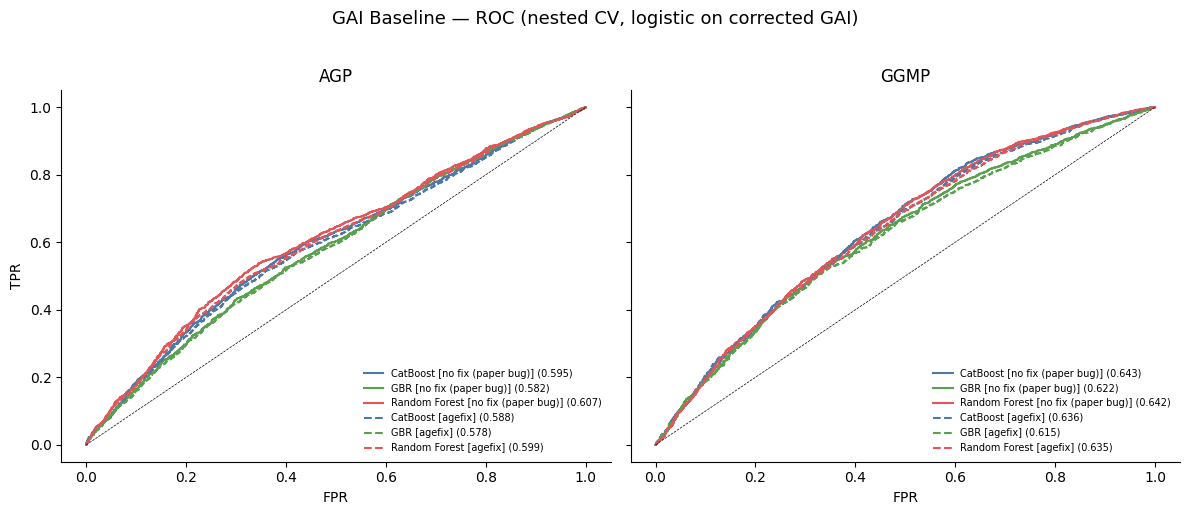

In [12]:
colors = {"CatBoost": "#4e79a7", "GBR": "#59a14f", "Random Forest": "#e15759"}
linestyles = {"no fix (paper bug)": "-", "agefix": "--"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, ds_name in zip(axes, ["AGP", "GGMP"]):
    for r in all_results:
        if r["dataset"] != ds_name:
            continue
        fpr, tpr, _ = roc_curve(r["y_valid"], r["oof_probs"])
        auc_val = roc_auc_score(r["y_valid"], r["oof_probs"])
        ax.plot(fpr, tpr,
                color=colors[r["model"]], ls=linestyles[r["variant"]],
                label=f"{r['model']} [{r['variant']}] ({auc_val:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.5)
    ax.set_title(ds_name, fontsize=12)
    ax.set_xlabel("FPR")
    ax.legend(fontsize=7, frameon=False, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("TPR")
fig.suptitle("GAI Baseline — ROC (nested CV, logistic on corrected GAI)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 8. Balanced accuracy comparison

Dot-and-whisker plot: each point is a fold BA, larger dot is the mean.

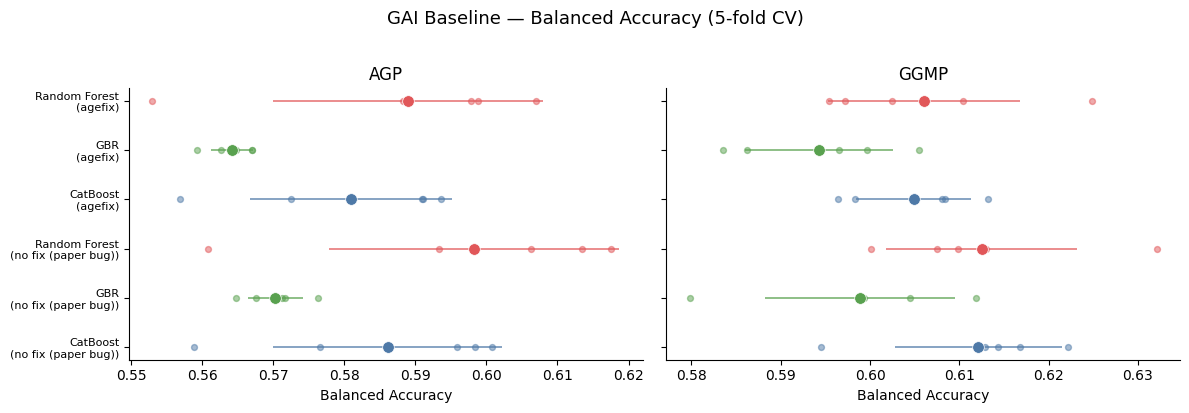

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, ds_name in zip(axes, ["AGP", "GGMP"]):
    ds_res = [r for r in all_results if r["dataset"] == ds_name]
    labels = [f"{r['model']}\n({r['variant']})" for r in ds_res]
    y_pos = np.arange(len(ds_res))
    
    for i, r in enumerate(ds_res):
        color = colors[r["model"]]
        # Individual folds
        ax.scatter(r["fold_ba"], [i] * 5, color=color, s=18, alpha=0.5, zorder=3)
        # Mean
        ax.scatter([r["ba_mean"]], [i], color=color, s=70, zorder=4,
                   edgecolors="white", linewidth=0.5)
        # Whisker
        ax.errorbar([r["ba_mean"]], [i], xerr=[r["ba_std"]], fmt="none",
                    ecolor=color, capsize=0, elinewidth=1.2, alpha=0.8)
    
    # Paper baseline
    #ax.axvline(0.68, color="grey", ls=":", lw=1, label="Paper baseline (0.68)")
    #ax.axvline(0.50, color="lightgrey", ls=":", lw=0.5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Balanced Accuracy")
    ax.set_title(ds_name, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    #ax.legend(fontsize=7, frameon=False)

fig.suptitle("GAI Baseline — Balanced Accuracy (5-fold CV)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 9. Comparison with pre-computed `my_output/` results

This section compares two evaluation styles for the same GAI concept.

**Paper-comparable view (historical comparability)**
- Train age regressor on healthy samples, then derive corrected GAI and classify.
- Useful to check whether we can reproduce published behavior and scale.
- Appropriate when discussing consistency with prior work.

**Strict view (deployment-relevant generalization)**
- Entire multi-stage pipeline is evaluated fold-wise using only training-fold information.
- Prevents in-sample optimism from Stage 1 (age regression) leaking into Stage 2 (classification).
- Appropriate for model selection and performance claims.

**Key pitfall in common paper-style implementations**
- If healthy samples used to train the age model are also scored in the same stage, corrected GAI can become artificially easy to separate.
- This can inflate downstream BA/AUC relative to true unseen-sample behavior.

**Are exact reproductions valid?**
- Yes, for comparability and reproducibility.
- But they answer a different question than strict generalization estimates.
- Therefore this notebook keeps both views side by side: one for literature alignment, one for decision-grade benchmarking.

In [14]:
import os

# Load pre-computed results (PyCaret CatBoost, paper-comparable style)
# and compute logistic regression baseline with threshold optimization
precomputed_rows = []
output_root = "my_output"
for folder in sorted(os.listdir(output_root)):
    result_path = os.path.join(output_root, folder, "result.tsv")
    if not os.path.isfile(result_path):
        continue

    df = pd.read_csv(result_path, sep="\t", index_col="id")
    df = df.dropna(subset=["corrected GAI"])
    y_pre = (df["health"] == "n").astype(int).values
    X_pre = df["corrected GAI"].values.reshape(-1, 1)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_ba, fold_auc = [], []
    for tri, tei in cv.split(X_pre, y_pre):
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(X_pre[tri], y_pre[tri])
        prob = lr.predict_proba(X_pre[tei])[:, 1]

        # Optimize threshold within the fold
        best_ba = 0
        for thr in np.arange(0.1, 0.9, 0.01):
            ba = balanced_accuracy_score(y_pre[tei], (prob >= thr).astype(int))
            if ba > best_ba:
                best_ba = ba

        fold_ba.append(best_ba)
        fold_auc.append(roc_auc_score(y_pre[tei], prob))

    precomputed_rows.append({
        "View": "Paper-comparable",
        "Source": f"my_output/{folder}",
        "Samples": len(df),
        "BA": f"{np.mean(fold_ba):.3f} ± {np.std(fold_ba):.3f}",
        "AUC": f"{np.mean(fold_auc):.3f} ± {np.std(fold_auc):.3f}",
    })

print("Paper-comparable view (precomputed pipeline artifacts):")
display(pd.DataFrame(precomputed_rows))

# Strict nested-CV reproduction
print("\nStrict nested-CV view (primary benchmark):")
if "all_results" not in globals():
    print("Run Section 5 first to populate all_results for strict nested-CV results.")
else:
    repro = [r for r in all_results if r["model"] == "CatBoost"]
    repro_df = pd.DataFrame([{
        "View": "Strict nested-CV",
        "Source": f"{r['dataset']} / {r['variant']}",
        "Samples": r["n_valid"],
        "BA": f"{r['ba_mean']:.3f} ± {r['ba_std']:.3f}",
        "AUC": f"{r['auc_mean']:.3f} ± {r['auc_std']:.3f}",
    } for r in repro])
    display(repro_df)

Paper-comparable view (precomputed pipeline artifacts):


,View,Source,Samples,BA,AUC
0,Paper-comparable,my_output/AGP,5350,0.658 ± 0.013,0.621 ± 0.023
1,Paper-comparable,my_output/AGP-agefix,5965,0.647 ± 0.008,0.604 ± 0.013
2,Paper-comparable,my_output/GGMP,5799,0.731 ± 0.007,0.686 ± 0.012
3,Paper-comparable,my_output/GGMP-agefix,6242,0.718 ± 0.009,0.668 ± 0.006



Strict nested-CV view (primary benchmark):


,View,Source,Samples,BA,AUC
0,Strict nested-CV,AGP / no fix (paper bug),5350,0.586 ± 0.016,0.595 ± 0.020
1,Strict nested-CV,AGP / agefix,5965,0.581 ± 0.014,0.588 ± 0.018
2,Strict nested-CV,GGMP / no fix (paper bug),5799,0.612 ± 0.009,0.643 ± 0.011
3,Strict nested-CV,GGMP / agefix,6242,0.605 ± 0.006,0.637 ± 0.011


## Summary

Use this notebook with a **two-baseline interpretation**:
- **Paper-comparable baseline**: for matching prior literature and communicating reproduction quality.
- **Strict nested-CV baseline**: for fair out-of-sample benchmarking and model selection.

For challenge progress and improvement claims, treat the strict nested-CV numbers as the primary benchmark.
Use paper-comparable numbers as contextual reference, not as the sole target.

Any direct-classification model (from `direct-classification.ipynb`) should be judged mainly against the strict baseline.

**Reference context**: the paper reports about 68% BA for AGP under its original workflow framing.